In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# EXTRACT - Load raw data from CSV
df = pd.read_csv("Superstore.csv", encoding='latin1')

print("Shape of data:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of data: (9994, 21)

First 5 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09/11/2013,12/11/2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13/06/2013,17/06/2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11/10/2012,18/10/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11/10/2012,18/10/2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
# TRANSFORM

# Check missing values
print("Missing values:\n", df.isnull().sum())

# Drop rows with null values
df = df.dropna()

# Select only required columns
df = df[['Category', 'Sub-Category', 'Sales', 'Profit', 'Quantity']]

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [7]:
df = df.drop_duplicates()

print("\nCleaned Data Shape:", df.shape)
print(df.head())


Cleaned Data Shape: (7729, 5)
          Category Sub-Category     Sales    Profit  Quantity
0        Furniture    Bookcases  261.9600   41.9136         2
1        Furniture       Chairs  731.9400  219.5820         3
2  Office Supplies       Labels   14.6200    6.8714         2
3        Furniture       Tables  957.5775 -383.0310         5
4  Office Supplies      Storage   22.3680    2.5164         2


In [8]:
# LOAD - Save cleaned data to new CSV
df.to_csv("Superstore_cleaned.csv", index=False)

print("Cleaned data loaded/saved successfully!")

Cleaned data loaded/saved successfully!


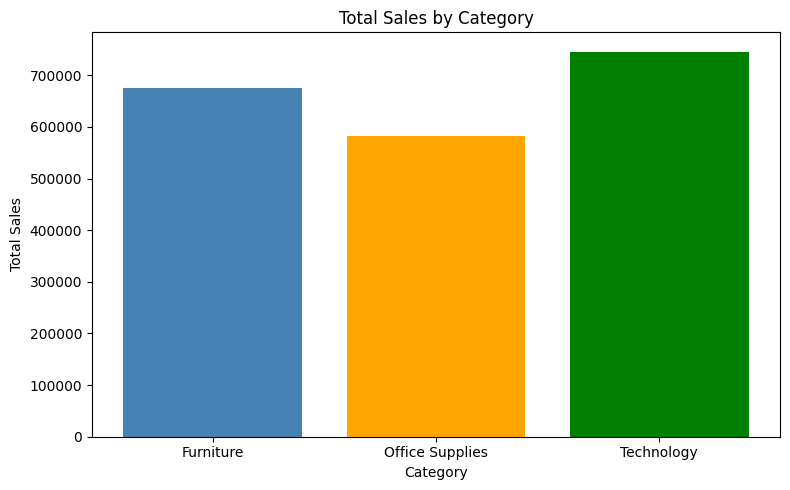

In [9]:
# VISUALIZE

# Bar chart - Total Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
plt.bar(category_sales.index, category_sales.values, color=['steelblue','orange','green'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

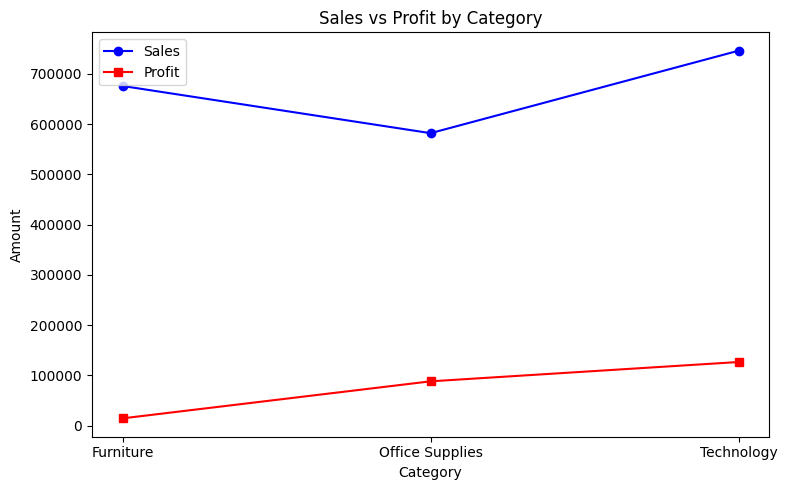

In [10]:
# Line chart - Sales vs Profit by Category
category_profit = df.groupby('Category')['Profit'].sum()

plt.figure(figsize=(8,5))
plt.plot(category_sales.index, category_sales.values, marker='o', label='Sales', color='blue')
plt.plot(category_profit.index, category_profit.values, marker='s', label='Profit', color='red')
plt.title('Sales vs Profit by Category')
plt.xlabel('Category')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.show()